# Table Extraction using pdfplumber + Table Transformer Structure Recognition

This notebook demonstrates extracting tables from PDFs using:
1. **pdfplumber** to detect table bounding boxes
2. **pdf2image** to render the table region as an image
3. **Table Transformer Structure Recognition** to detect rows/columns/cells
4. **pdfplumber** to extract text from each cell

### Import dependencies

In [102]:
import pdfplumber
from pdf2image import convert_from_path
from PIL import Image, ImageDraw
import torch
from transformers import AutoImageProcessor, TableTransformerForObjectDetection

In [103]:
# Load structure recognition model (not detection - we use pdfplumber for that)
# Use use_fast=False to avoid SizeDict compatibility issue
structure_processor = AutoImageProcessor.from_pretrained(
    "microsoft/table-transformer-structure-recognition-v1.1-all",
    use_fast=False
)
structure_model = TableTransformerForObjectDetection.from_pretrained(
    "microsoft/table-transformer-structure-recognition-v1.1-all"
)

Loading weights: 100%|██████████| 367/367 [00:00<00:00, 1601.97it/s, Materializing param=model.query_position_embeddings.weight]                                                        


### Load PDF and use pdfplumber to find table bbox

In [104]:
pdf_path = "example sources/bmj-2021-067731.full.pdf"
page_num = 3  # 1-indexed for display, will use page_num-1 for 0-indexed access

# Open PDF with pdfplumber
pdf = pdfplumber.open(pdf_path)
page = pdf.pages[page_num - 1]

print(f"PDF page dimensions: {page.width} x {page.height} points")

# Use pdfplumber to find tables
tables = page.find_tables()
print(f"Found {len(tables)} table(s) on page {page_num}")

if tables:
    for i, table in enumerate(tables):
        print(f"Table {i+1} bbox (PDF coords): {table.bbox}")

PDF page dimensions: 595.276 x 793.701 points
Found 1 table(s) on page 3
Table 1 bbox (PDF coords): (34.016, 72.40868000000007, 345.63800000000003, 223.51300000000003)


In [105]:
# Visualize detected tables using pdfplumber's debug view
if tables:
    im = page.to_image(resolution=150)
    im.debug_tablefinder()
else:
    print("No tables found on this page.")

### Render the table region as an image

In [106]:
if not tables:
    raise ValueError("No tables found on this page")

# Use the first detected table
table = tables[0]
table_bbox_pdf = table.bbox  # (x0, y0, x1, y1) in PDF points
print(f"Table bbox (PDF coords): {table_bbox_pdf}")

# Render the full page at high DPI
DPI = 200
page_images = convert_from_path(pdf_path, first_page=page_num, last_page=page_num, dpi=DPI)
page_image = page_images[0]

print(f"Full page image size: {page_image.size} pixels")

Table bbox (PDF coords): (34.016, 72.40868000000007, 345.63800000000003, 223.51300000000003)
Full page image size: (1654, 2205) pixels


Table bbox (pixels): (94, 201, 960, 620)
Cropped table image size: (866, 419) pixels


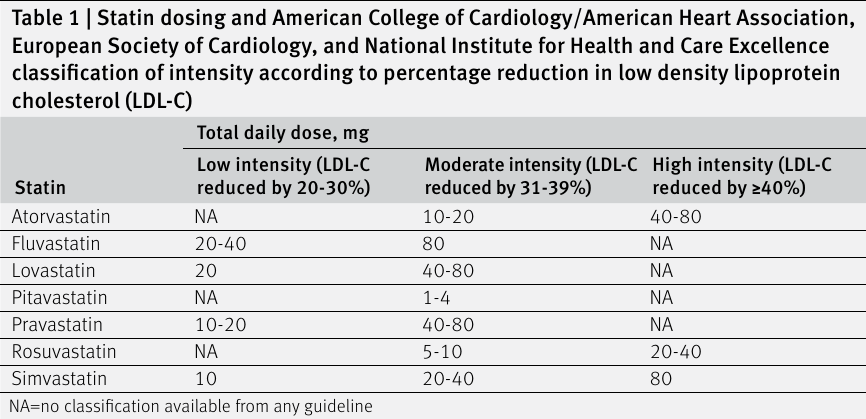

In [107]:
# Convert PDF bbox to pixel coordinates for cropping
def pdf_to_pixel(pdf_bbox, page_width, page_height, img_width, img_height):
    """Convert PDF coordinates to pixel coordinates."""
    x0, y0, x1, y1 = pdf_bbox
    scale_x = img_width / page_width
    scale_y = img_height / page_height
    return (
        int(x0 * scale_x),
        int(y0 * scale_y),
        int(x1 * scale_x),
        int(y1 * scale_y)
    )

# Crop the table region from the page image
table_bbox_pixels = pdf_to_pixel(
    table_bbox_pdf, 
    page.width, page.height,
    page_image.width, page_image.height
)
print(f"Table bbox (pixels): {table_bbox_pixels}")

table_image = page_image.crop(table_bbox_pixels)
print(f"Cropped table image size: {table_image.size} pixels")
table_image

### Run TATR Structure Model to get row/column/cell bboxes

In [108]:
# Run structure recognition on the cropped table image
# Explicitly set size to avoid config issue
inputs = structure_processor(
    images=table_image, 
    return_tensors="pt",
    size={"shortest_edge": 800, "longest_edge": 1333}
)

with torch.no_grad():
    outputs = structure_model(**inputs)

# Post-process to get bounding boxes
target_sizes = torch.tensor([table_image.size[::-1]])  # (height, width)
results = structure_processor.post_process_object_detection(
    outputs, threshold=0.5, target_sizes=target_sizes
)[0]

# Get label mapping
id2label = structure_model.config.id2label

# Count detected elements by type
from collections import Counter
label_counts = Counter([id2label[label.item()] for label in results['labels']])

print("Detected table structure elements:")
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count}")

Detected table structure elements:
  table: 1
  table column: 4
  table column header: 1
  table row: 10
  table spanning cell: 3


In [109]:
# Organize results by element type
structure_elements = {}
for box, score, label_id in zip(results['boxes'], results['scores'], results['labels']):
    label = id2label[label_id.item()]
    if label not in structure_elements:
        structure_elements[label] = []
    structure_elements[label].append({
        'bbox': box.tolist(),
        'score': score.item()
    })

# Sort rows by y-coordinate (top to bottom)
if 'table row' in structure_elements:
    structure_elements['table row'].sort(key=lambda x: x['bbox'][1])
    print(f"Found {len(structure_elements['table row'])} rows")

# Sort columns by x-coordinate (left to right)
if 'table column' in structure_elements:
    structure_elements['table column'].sort(key=lambda x: x['bbox'][0])
    print(f"Found {len(structure_elements['table column'])} columns")

# Get spanning cells
spanning_cells = structure_elements.get('table spanning cell', [])
print(f"Found {len(spanning_cells)} spanning cells to filter out")

def overlaps_spanning_cell(row_bbox, spanning_cells, threshold=0.5):
    """Check if a row significantly overlaps with any spanning cell."""
    row_y0, row_y1 = row_bbox[1], row_bbox[3]
    row_height = row_y1 - row_y0
    
    for span in spanning_cells:
        span_y0, span_y1 = span['bbox'][1], span['bbox'][3]
        # Calculate vertical overlap
        overlap_y0 = max(row_y0, span_y0)
        overlap_y1 = min(row_y1, span_y1)
        overlap = max(0, overlap_y1 - overlap_y0)
        
        if overlap / row_height > threshold:
            return True
    return False

# Filter out rows that overlap with spanning cells
filtered_rows = []
for row in structure_elements.get('table row', []):
    if not overlaps_spanning_cell(row['bbox'], spanning_cells):
        filtered_rows.append(row)
    else:
        print(f"  Filtered out row at y={row['bbox'][1]:.0f}")

print(f"\nKept {len(filtered_rows)} rows after filtering")

# Compute cells from filtered rows and columns
def compute_cell_bbox(row_bbox, col_bbox):
    """Compute cell bbox as intersection of row and column."""
    x0 = max(row_bbox[0], col_bbox[0])
    y0 = max(row_bbox[1], col_bbox[1])
    x1 = min(row_bbox[2], col_bbox[2])
    y1 = min(row_bbox[3], col_bbox[3])
    
    if x1 > x0 and y1 > y0:
        return [x0, y0, x1, y1]
    return None

# Generate cells from filtered row/column intersections
cells = []
columns = structure_elements.get('table column', [])
for row in filtered_rows:
    for col in columns:
        cell_bbox = compute_cell_bbox(row['bbox'], col['bbox'])
        if cell_bbox:
            cells.append({
                'bbox': cell_bbox,
                'score': min(row['score'], col['score'])
            })

# Sort cells by position (top-to-bottom, left-to-right)
cells.sort(key=lambda x: (x['bbox'][1], x['bbox'][0]))
structure_elements['table cell'] = cells
print(f"Computed {len(cells)} cells from {len(filtered_rows)} rows x {len(columns)} columns")

Found 10 rows
Found 4 columns
Found 3 spanning cells to filter out
  Filtered out row at y=32
  Filtered out row at y=114
  Filtered out row at y=146

Kept 7 rows after filtering
Computed 28 cells from 7 rows x 4 columns


Elements:
  table column: 4
  table row: 10
  table spanning cell: 3
  table column header: 1
  table: 1
  table cell: 28

Showing computed cells (red):


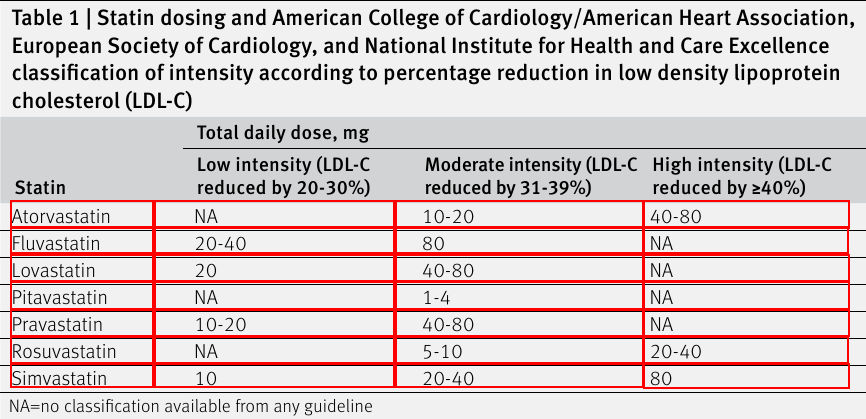

In [110]:
# Visualize the detected structure on the table image
def visualize_structure(image, elements, show_labels=None):
    """Draw detected structure elements on the image."""
    colors = {
        'table': 'blue',
        'table row': 'green',
        'table column': 'orange', 
        'table cell': 'red',
        'table column header': 'purple',
        'table projected row header': 'cyan',
        'table spanning cell': 'magenta'
    }
    
    if show_labels is None:
        show_labels = list(elements.keys())
    
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)
    
    for label in show_labels:
        if label in elements:
            color = colors.get(label, 'red')
            for elem in elements[label]:
                x0, y0, x1, y1 = elem['bbox']
                draw.rectangle([x0, y0, x1, y1], outline=color, width=2)
    
    return img_copy

# Print what was detected/computed
print("Elements:")
for label, items in structure_elements.items():
    print(f"  {label}: {len(items)}")

# Show cells (computed from row/column intersections) overlaid on table image
print("\nShowing computed cells (red):")
annotated = visualize_structure(table_image, structure_elements, ['table cell'])
annotated

### Map cell bboxes back to PDF coordinates

In [111]:
def cell_pixel_to_pdf(cell_bbox_pixels, table_bbox_pixels, table_bbox_pdf):
    """
    Convert cell bbox from pixel coordinates (relative to cropped table image)
    to PDF coordinates.
    
    Args:
        cell_bbox_pixels: (x0, y0, x1, y1) in pixels relative to table image
        table_bbox_pixels: (x0, y0, x1, y1) table bbox in page pixels
        table_bbox_pdf: (x0, y0, x1, y1) table bbox in PDF points
    
    Returns:
        (x0, y0, x1, y1) in PDF coordinates
    """
    # Table dimensions
    table_pixel_width = table_bbox_pixels[2] - table_bbox_pixels[0]
    table_pixel_height = table_bbox_pixels[3] - table_bbox_pixels[1]
    table_pdf_width = table_bbox_pdf[2] - table_bbox_pdf[0]
    table_pdf_height = table_bbox_pdf[3] - table_bbox_pdf[1]
    
    # Scale factors
    scale_x = table_pdf_width / table_pixel_width
    scale_y = table_pdf_height / table_pixel_height
    
    # Convert cell coordinates
    cx0, cy0, cx1, cy1 = cell_bbox_pixels
    
    pdf_x0 = table_bbox_pdf[0] + (cx0 * scale_x)
    pdf_y0 = table_bbox_pdf[1] + (cy0 * scale_y)
    pdf_x1 = table_bbox_pdf[0] + (cx1 * scale_x)
    pdf_y1 = table_bbox_pdf[1] + (cy1 * scale_y)
    
    return (pdf_x0, pdf_y0, pdf_x1, pdf_y1)

# Convert all cell bboxes to PDF coordinates
cells_pdf = []
if 'table cell' in structure_elements:
    for cell in structure_elements['table cell']:
        cell_pdf_bbox = cell_pixel_to_pdf(
            cell['bbox'],
            table_bbox_pixels,
            table_bbox_pdf
        )
        cells_pdf.append({
            'bbox_pixels': cell['bbox'],
            'bbox_pdf': cell_pdf_bbox,
            'score': cell['score']
        })

print(f"Converted {len(cells_pdf)} cells to PDF coordinates")
if cells_pdf:
    print(f"\nExample cell:")
    print(f"  Pixels: {cells_pdf[0]['bbox_pixels']}")
    print(f"  PDF:    {cells_pdf[0]['bbox_pdf']}")

Converted 28 cells to PDF coordinates

Example cell:
  Pixels: [10.566998481750488, 200.96571350097656, 153.2642364501953, 228.21566772460938]
  PDF:    (37.81843556683609, 144.8831131309783, 89.16670195275147, 154.7102868851386)


### Extract text from each cell using pdfplumber

In [112]:
# Extract text from each cell
def extract_cell_text(page, cell_bbox_pdf):
    """Extract text from a cell using pdfplumber's crop."""
    try:
        # Ensure bbox is within page bounds
        x0 = max(0, cell_bbox_pdf[0])
        y0 = max(0, cell_bbox_pdf[1])
        x1 = min(page.width, cell_bbox_pdf[2])
        y1 = min(page.height, cell_bbox_pdf[3])
        
        if x1 <= x0 or y1 <= y0:
            return ""
        
        cropped = page.crop((x0, y0, x1, y1))
        text = cropped.extract_text()
        return text.strip() if text else ""
    except Exception as e:
        return f"[Error: {e}]"

# Extract text for all cells
for i, cell in enumerate(cells_pdf):
    cell['text'] = extract_cell_text(page, cell['bbox_pdf'])

# Display extracted text
print("Extracted cell contents:")
print("=" * 60)
for i, cell in enumerate(cells_pdf):
    text_preview = cell['text'][:50] + "..." if len(cell['text']) > 50 else cell['text']
    print(f"Cell {i+1}: {text_preview if text_preview else '[empty]'}")

Extracted cell contents:
Cell 1: Atorvastatin
Cell 2: NA
Cell 3: 10-20
Cell 4: 40-80
Cell 5: Atorvastatin
Fluvastatin
Cell 6: NA
20-40
Cell 7: 10-20
80
Cell 8: 40-80
NA
Cell 9: FLlouvvaassttaattinin
Cell 10: 2200-40
Cell 11: 8400-80
Cell 12: NNAA
Cell 13: LPoitvaavsatsattaintin
Cell 14: N20A
Cell 15: 410-4-80
Cell 16: NNAA
Cell 17: PPirtaavvaassttaattiinn
Cell 18: N10A-20
Cell 19: 14-04-80
Cell 20: NNAA
Cell 21: PRroasvuavsatsattaintin
Cell 22: 1N0A-20
Cell 23: 450-1-800
Cell 24: N20A-40
Cell 25: Simvastatin
Cell 26: 10
Cell 27: 20-40
Cell 28: 80


### Organize cells into rows and columns

In [113]:
def organize_cells_into_grid(cells, row_tolerance=10):
    """
    Organize cells into a 2D grid based on their positions.
    
    Args:
        cells: List of cell dicts with 'bbox_pixels' and 'text'
        row_tolerance: Pixels tolerance for grouping cells into same row
    
    Returns:
        List of rows, where each row is a list of cell texts
    """
    if not cells:
        return []
    
    # Group cells by row (based on y-coordinate)
    rows = []
    current_row = [cells[0]]
    current_y = cells[0]['bbox_pixels'][1]
    
    for cell in cells[1:]:
        cell_y = cell['bbox_pixels'][1]
        if abs(cell_y - current_y) <= row_tolerance:
            # Same row
            current_row.append(cell)
        else:
            # New row - sort current row by x and save
            current_row.sort(key=lambda c: c['bbox_pixels'][0])
            rows.append(current_row)
            current_row = [cell]
            current_y = cell_y
    
    # Don't forget the last row
    current_row.sort(key=lambda c: c['bbox_pixels'][0])
    rows.append(current_row)
    
    return rows

# Organize into grid
rows = organize_cells_into_grid(cells_pdf)
print(f"Organized into {len(rows)} rows")

# Display as table
print("\nExtracted Table:")
print("=" * 80)
for i, row in enumerate(rows):
    row_texts = [cell['text'] for cell in row]
    print(f"Row {i+1}: {row_texts}")

Organized into 7 rows

Extracted Table:
Row 1: ['Atorvastatin', 'NA', '10-20', '40-80']
Row 2: ['Atorvastatin\nFluvastatin', 'NA\n20-40', '10-20\n80', '40-80\nNA']
Row 3: ['FLlouvvaassttaattinin', '2200-40', '8400-80', 'NNAA']
Row 4: ['LPoitvaavsatsattaintin', 'N20A', '410-4-80', 'NNAA']
Row 5: ['PPirtaavvaassttaattiinn', 'N10A-20', '14-04-80', 'NNAA']
Row 6: ['PRroasvuavsatsattaintin', '1N0A-20', '450-1-800', 'N20A-40']
Row 7: ['Simvastatin', '10', '20-40', '80']


In [114]:
# Convert to pandas DataFrame for better display
import pandas as pd

if rows:
    # Use first row as header if it looks like a header
    header_row = [cell['text'] for cell in rows[0]]
    data_rows = [[cell['text'] for cell in row] for row in rows[1:]]
    
    # Pad rows to same length
    max_cols = max(len(row) for row in [header_row] + data_rows)
    header_row = header_row + [''] * (max_cols - len(header_row))
    data_rows = [row + [''] * (max_cols - len(row)) for row in data_rows]
    
    df = pd.DataFrame(data_rows, columns=header_row)
    display(df)
else:
    print("No cells to display")

,Atorvastatin,NA,10-20,40-80
0,Atorvastatin\nFluvastatin,NA\n20-40,10-20\n80,40-80\nNA
1,FLlouvvaassttaattinin,2200-40,8400-80,NNAA
2,LPoitvaavsatsattaintin,N20A,410-4-80,NNAA
3,PPirtaavvaassttaattiinn,N10A-20,14-04-80,NNAA
4,PRroasvuavsatsattaintin,1N0A-20,450-1-800,N20A-40
5,Simvastatin,10,20-40,80


In [115]:
# Clean up
pdf.close()

## Extract tables from all pages

Loop through every page using pdfplumber for table detection and TATR for structure recognition.

In [ ]:
def extract_tables_all_pages(pdf_path, max_pages=None, dpi=200):
    """
    Extract tables from all pages using pdfplumber + TATR structure recognition.
    
    Args:
        pdf_path: Path to the PDF file
        max_pages: Optional limit on pages to process
        dpi: Resolution for rendering pages
    
    Returns:
        dict with results per page
    """
    results = {}
    
    with pdfplumber.open(pdf_path) as pdf:
        total_pages = len(pdf.pages)
        pages_to_process = min(total_pages, max_pages) if max_pages else total_pages
        
        print(f"Processing {pages_to_process} of {total_pages} pages...")
        print("=" * 80)
        
        for page_idx in range(pages_to_process):
            page_num = page_idx + 1
            page = pdf.pages[page_idx]
            
            print(f"\n{'='*80}")
            print(f"PAGE {page_num}")
            print(f"{'='*80}")
            
            # Display page image
            page_img = page.to_image(resolution=100)
            display(page_img)
            
            # Find tables using pdfplumber
            tables = page.find_tables()
            
            if not tables:
                print("No tables found on this page.")
                results[page_num] = {'tables': [], 'dataframes': []}
                continue
            
            print(f"Found {len(tables)} table(s)")
            
            page_results = []
            
            for table_idx, table in enumerate(tables):
                print(f"\n--- Table {table_idx + 1} ---")
                print(f"Bbox: {table.bbox}")
                
                try:
                    # Render page and crop table region
                    page_images = convert_from_path(
                        pdf_path, 
                        first_page=page_num, 
                        last_page=page_num, 
                        dpi=dpi
                    )
                    page_image = page_images[0]
                    
                    # Convert PDF bbox to pixels
                    table_bbox_pdf = table.bbox
                    scale_x = page_image.width / page.width
                    scale_y = page_image.height / page.height
                    table_bbox_pixels = (
                        int(table_bbox_pdf[0] * scale_x),
                        int(table_bbox_pdf[1] * scale_y),
                        int(table_bbox_pdf[2] * scale_x),
                        int(table_bbox_pdf[3] * scale_y)
                    )
                    
                    # Crop table image
                    table_image = page_image.crop(table_bbox_pixels)
                    print(f"Table image size: {table_image.size}")
                    
                    # Run TATR structure recognition
                    inputs = structure_processor(
                        images=table_image,
                        return_tensors="pt",
                        size={"shortest_edge": 800, "longest_edge": 1333}
                    )
                    
                    with torch.no_grad():
                        outputs = structure_model(**inputs)
                    
                    target_sizes = torch.tensor([table_image.size[::-1]])
                    det_results = structure_processor.post_process_object_detection(
                        outputs, threshold=0.5, target_sizes=target_sizes
                    )[0]
                    
                    # Organize by element type
                    elements = {}
                    for box, score, label_id in zip(det_results['boxes'], det_results['scores'], det_results['labels']):
                        label = id2label[label_id.item()]
                        if label not in elements:
                            elements[label] = []
                        elements[label].append({'bbox': box.tolist(), 'score': score.item()})
                    
                    # Print detected elements
                    print("Detected:", {k: len(v) for k, v in elements.items()})
                    
                    # Filter rows overlapping spanning cells
                    spanning_cells = elements.get('table spanning cell', [])
                    rows = sorted(elements.get('table row', []), key=lambda x: x['bbox'][1])
                    cols = sorted(elements.get('table column', []), key=lambda x: x['bbox'][0])
                    
                    filtered_rows = []
                    for row in rows:
                        row_y0, row_y1 = row['bbox'][1], row['bbox'][3]
                        row_height = row_y1 - row_y0
                        overlaps = False
                        for span in spanning_cells:
                            span_y0, span_y1 = span['bbox'][1], span['bbox'][3]
                            overlap = max(0, min(row_y1, span_y1) - max(row_y0, span_y0))
                            if overlap / row_height > 0.5:
                                overlaps = True
                                break
                        if not overlaps:
                            filtered_rows.append(row)
                    
                    print(f"Rows after filtering: {len(filtered_rows)} (from {len(rows)})")
                    
                    # Compute cells from row/column intersections
                    cells = []
                    for row in filtered_rows:
                        for col in cols:
                            x0 = max(row['bbox'][0], col['bbox'][0])
                            y0 = max(row['bbox'][1], col['bbox'][1])
                            x1 = min(row['bbox'][2], col['bbox'][2])
                            y1 = min(row['bbox'][3], col['bbox'][3])
                            if x1 > x0 and y1 > y0:
                                cells.append({'bbox': [x0, y0, x1, y1]})
                    
                    cells.sort(key=lambda x: (x['bbox'][1], x['bbox'][0]))
                    print(f"Computed {len(cells)} cells")
                    
                    # Visualize cells on table image
                    img_annotated = table_image.copy()
                    draw = ImageDraw.Draw(img_annotated)
                    for cell in cells:
                        draw.rectangle(cell['bbox'], outline='red', width=2)
                    display(img_annotated)
                    
                    # Extract text from cells
                    table_pixel_w = table_bbox_pixels[2] - table_bbox_pixels[0]
                    table_pixel_h = table_bbox_pixels[3] - table_bbox_pixels[1]
                    table_pdf_w = table_bbox_pdf[2] - table_bbox_pdf[0]
                    table_pdf_h = table_bbox_pdf[3] - table_bbox_pdf[1]
                    
                    for cell in cells:
                        cx0, cy0, cx1, cy1 = cell['bbox']
                        pdf_x0 = table_bbox_pdf[0] + (cx0 * table_pdf_w / table_pixel_w)
                        pdf_y0 = table_bbox_pdf[1] + (cy0 * table_pdf_h / table_pixel_h)
                        pdf_x1 = table_bbox_pdf[0] + (cx1 * table_pdf_w / table_pixel_w)
                        pdf_y1 = table_bbox_pdf[1] + (cy1 * table_pdf_h / table_pixel_h)
                        
                        try:
                            cropped = page.crop((
                                max(0, pdf_x0), max(0, pdf_y0),
                                min(page.width, pdf_x1), min(page.height, pdf_y1)
                            ))
                            cell['text'] = (cropped.extract_text() or '').strip()
                        except:
                            cell['text'] = ''
                    
                    # Organize into grid
                    if cells:
                        grid_rows = []
                        current_row = [cells[0]]
                        current_y = cells[0]['bbox'][1]
                        
                        for cell in cells[1:]:
                            if abs(cell['bbox'][1] - current_y) <= 10:
                                current_row.append(cell)
                            else:
                                current_row.sort(key=lambda c: c['bbox'][0])
                                grid_rows.append([c['text'] for c in current_row])
                                current_row = [cell]
                                current_y = cell['bbox'][1]
                        
                        current_row.sort(key=lambda c: c['bbox'][0])
                        grid_rows.append([c['text'] for c in current_row])
                        
                        # Create DataFrame
                        if len(grid_rows) > 1:
                            max_cols = max(len(r) for r in grid_rows)
                            grid_rows = [r + [''] * (max_cols - len(r)) for r in grid_rows]
                            df = pd.DataFrame(grid_rows[1:], columns=grid_rows[0])
                        else:
                            df = pd.DataFrame(grid_rows)
                        
                        print(f"\nExtracted Table ({len(df)} rows):")
                        display(df)
                        page_results.append({'cells': cells, 'dataframe': df})
                    
                except Exception as e:
                    print(f"Error processing table: {e}")
                    # Fallback to pdfplumber extraction
                    print("Falling back to pdfplumber extraction...")
                    table_data = table.extract()
                    if table_data and len(table_data) > 1:
                        df = pd.DataFrame(table_data[1:], columns=table_data[0])
                        display(df)
                        page_results.append({'dataframe': df})
            
            results[page_num] = {'tables': page_results}
    
    return results

In [ ]:
# Run extraction on all pages (limit to 10 for demo)
all_results = extract_tables_all_pages(
    "example sources/bmj-2021-067731.full.pdf",
    max_pages=10
)

In [ ]:
# Summary of extraction
print("\nEXTRACTION SUMMARY")
print("=" * 50)

total_tables = 0
for page_num, data in all_results.items():
    num_tables = len(data.get('tables', []))
    total_tables += num_tables
    status = f"{num_tables} table(s)" if num_tables > 0 else "No tables"
    print(f"Page {page_num}: {status}")

print("-" * 50)
print(f"TOTAL: {total_tables} tables across {len(all_results)} pages")